In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from hydra import initialize, compose
from rdkit import Chem
from collections import defaultdict
from itertools import accumulate, chain
from ergochemics.mapping import rc_to_nest, get_reaction_center
from ergochemics.draw import draw_reaction, draw_molecule
from IPython.display import SVG
from cgr.ml import sep_aidx_to_bin_label, scrub_anonymous_template_atoms
import yaml
from ast import literal_eval
import json
from tqdm import tqdm

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score,
    auc
)

from sklearn.calibration import CalibrationDisplay

with initialize(version_base=None, config_path="../configs/filepaths"):
    cfg = compose(config_name="filepaths")

mlflow.set_tracking_uri(f"file://{cfg.mlruns}")

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "axes.titlesize": 16,
})

In [19]:
def get_min_dist_to_rc(am_rxn: str, rc: list[list[list[int]], list[list[int]]]) -> list[list[list[int]], list[list[int]]]:
    mols = [[Chem.MolFromSmiles(elt) for elt in side.split('.')] for side in am_rxn.split('>>')]
    min_dists = [[], []]
    for i, side_rc in enumerate(rc):
        for mol, rc in zip(mols[i], side_rc):
            for atom in mol.GetAtoms():
                aidx = atom.GetIdx()
                min_dist = min(len(Chem.GetShortestPath(mol, aidx, rcidx)) - 1 if aidx != rcidx else 0 for rcidx in rc)

                min_dists[i].append(min_dist)
    return [np.array(elt).reshape(-1, 1) for elt in min_dists]


In [20]:
experiment_name = "direct_mcsa_only_v2" # outer_splits
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment:
    df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
else:
    print(f"Experiment '{experiment_name}' not found.")

In [21]:
df.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.test_auroc,metrics.test_auprc,metrics.test_loss,metrics.test_precision,...,params.data/outer_splitter/n_splits,params.model/mp_depth,params.training/init_lr,params.training/pw_scl,params.direct_mcsa_only,tags.mlflow.source.name,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.user,tags.source
0,e08dd14fa6e248118ee289bb47c2d33b,933762272843939934,FINISHED,file:///home/stef/cgr/artifacts/mlruns/9337622...,2026-03-19 21:03:19.935000+00:00,2026-03-19 21:06:22.335000+00:00,0.980551,0.945412,0.303688,0.801051,...,5,3,0.0001,1.1761158696973697,True,scripts/train.py,LOCAL,welcoming-goose-256,stef,train.py
1,123e0ce022b24cbfb5ca3bfc52c0aa00,933762272843939934,FINISHED,file:///home/stef/cgr/artifacts/mlruns/9337622...,2026-03-19 21:03:06.275000+00:00,2026-03-19 21:06:13.609000+00:00,0.975881,0.934133,0.284783,0.837555,...,5,3,0.0001,0.8546848976796929,True,scripts/train.py,LOCAL,gifted-stag-923,stef,train.py
2,a171ae1553ce4043961ebfb51689a242,933762272843939934,FINISHED,file:///home/stef/cgr/artifacts/mlruns/9337622...,2026-03-19 21:02:57.859000+00:00,2026-03-19 21:06:29.479000+00:00,0.979278,0.946242,0.392520,0.925605,...,5,3,0.0001,1.2418949803959747,True,scripts/train.py,LOCAL,skillful-duck-565,stef,train.py
3,53e50935ec894490b24ca21e9ecd29b8,933762272843939934,FINISHED,file:///home/stef/cgr/artifacts/mlruns/9337622...,2026-03-19 21:02:27.914000+00:00,2026-03-19 21:06:01.632000+00:00,0.972141,0.936088,0.355566,0.721121,...,5,3,0.0001,0.8972273533012429,True,scripts/train.py,LOCAL,capricious-snake-498,stef,train.py
4,af50b0448d454cff83689e189d05e39f,933762272843939934,FINISHED,file:///home/stef/cgr/artifacts/mlruns/9337622...,2026-03-19 21:02:02.841000+00:00,2026-03-19 21:03:12.987000+00:00,0.956261,0.903910,0.422534,0.821531,...,5,3,0.0001,0.7354339392438477,True,scripts/train.py,LOCAL,valuable-ant-887,stef,train.py


In [22]:
# Copy configs to conf dir to train production model
for i, row in df.iterrows():
    fn = f"dmo_outer_split_{row['params.data/outer_split_idx']}.yaml"
    out_path = Path(cfg.configs) / "full" / fn

    config = defaultdict(dict)
    for k, v in row.items():
        if k.startswith("params.") and "/" in k:
            k_out, k_in, *_ = k.removeprefix("params.").split("/")
            try:
                config[k_out][k_in] = literal_eval(v)
            except ValueError:
                config[k_out][k_in] = v


    with open(out_path, "w") as f:
        yaml.dump(dict(config), f)
    
    print(f"Saving config to: {out_path}")

Saving config to: /home/stef/cgr/configs/full/dmo_outer_split_4.yaml
Saving config to: /home/stef/cgr/configs/full/dmo_outer_split_3.yaml
Saving config to: /home/stef/cgr/configs/full/dmo_outer_split_2.yaml
Saving config to: /home/stef/cgr/configs/full/dmo_outer_split_1.yaml
Saving config to: /home/stef/cgr/configs/full/dmo_outer_split_0.yaml


In [23]:
df.sort_values(
    by=["metrics.test_auprc"],
    ascending=False,
    inplace=True,
)
df[[*[col for col in df.columns if col.startswith("metrics.") or col.startswith("params.")]]].head(10)

,metrics.test_auroc,metrics.test_auprc,metrics.test_loss,metrics.test_precision,metrics.epoch,metrics.test_recall,metrics.test_acc,metrics.train_loss,params.training/warmup_epochs,params.data/outer_splitter/_target_,...,params.data/inner_splitter/shuffle,params.data/outer_splitter/shuffle,params.final_lr,params.study_version,params.data/outer_split_idx,params.data/outer_splitter/n_splits,params.model/mp_depth,params.training/init_lr,params.training/pw_scl,params.direct_mcsa_only
2,0.979278,0.946242,0.392520,0.925605,38.0,0.846747,0.958689,0.299189,2,sklearn.model_selection.GroupKFold,...,True,True,0.001,0,2,5,3,0.0001,1.2418949803959747,True
0,0.980551,0.945412,0.303688,0.801051,30.0,0.921290,0.940667,0.314696,2,sklearn.model_selection.GroupKFold,...,True,True,0.001,0,4,5,3,0.0001,1.1761158696973697,True
3,0.972141,0.936088,0.355566,0.721121,32.0,0.939747,0.904386,0.259364,2,sklearn.model_selection.GroupKFold,...,True,True,0.001,0,1,5,3,0.0001,0.8972273533012429,True
1,0.975881,0.934133,0.284783,0.837555,28.0,0.867149,0.945643,0.269524,2,sklearn.model_selection.GroupKFold,...,True,True,0.001,0,3,5,3,0.0001,0.8546848976796929,True
4,0.956261,0.903910,0.422534,0.821531,36.0,0.786046,0.917870,0.364135,2,sklearn.model_selection.GroupKFold,...,True,True,0.001,0,0,5,3,0.0001,0.7354339392438477,True


In [24]:
df['metrics.test_auroc'].mean()

np.float64(0.9728220178551105)

In [25]:
preds = []
for _, row in df[df['params.objective'] == 'val_auprc'].iterrows():
    preds.append(
        pd.read_parquet(
            Path(row['artifact_uri'].replace("file:///home/spn1560/coarse-grain-rxns", "..")) / "predictions.parquet"
        )
    )

pred_df = pd.concat(preds, ignore_index=True)
pred_df.head()

,rxn_id,aidx,y,y_pred
0,4fc554b86bb64504ce3bb78f4c02accc82779129,0,0.0,0.392191
1,4fc554b86bb64504ce3bb78f4c02accc82779129,1,1.0,0.998547
2,4fc554b86bb64504ce3bb78f4c02accc82779129,2,1.0,0.895299
3,4fc554b86bb64504ce3bb78f4c02accc82779129,3,1.0,0.986221
4,09fd1a14c234cf101f02dd783ab990bc13f7f9af,0,1.0,0.987600


In [26]:
full = pd.read_parquet(
    Path(cfg.mappings) / "mapped_known_reactions_x_mechinformed_rules.parquet"
)
full = full[full['rxn_id'].isin(pred_df['rxn_id'].unique())]
full["template_aidxs"] = full["template_aidxs"].apply(rc_to_nest)
full['template_aidxs'] = full.apply(lambda x: scrub_anonymous_template_atoms(x.template_aidxs, x.rule), axis=1) # Scrub anonymous atoms from aidxs
full["reaction_center"] = full["am_smarts"].apply(get_reaction_center) # Get the actual reaction center from the atom mapped reactions
full["min_dist_to_rc"] = full.apply(lambda x: get_min_dist_to_rc(x.am_smarts, x.reaction_center)[0], axis=1) # Get min dist to reaction center for lhs
full["binary_label"] = full.apply(lambda x: sep_aidx_to_bin_label(x.am_smarts, x.template_aidxs)[0], axis=1) # Convert aidxs to binary labels for block mol
full.head()

,rxn_id,smarts,am_smarts,rule,template_aidxs,rule_id,reaction_center,min_dist_to_rc,binary_label
0,4fc554b86bb64504ce3bb78f4c02accc82779129,*C#N.O>>*C(N)=O,[*:4][C:1]#[N:2].[OH2:3]>>[*:4][C:1]([NH2:2])=...,[C&D2&v4&H0&+0&!R&z2:1]#[N&D1&v3&H0&+0&!R:2].[...,"(((1, 2), (0,)), ((1, 2, 3),))",101,"[[[1, 2], [0]], [[1, 2, 3]]]","[[1], [0], [0], [0]]","[[0.0], [1.0], [1.0], [1.0]]"
60,ec7efbf70ba503686669cbbf73709cda973b2d3d,*C(=O)C(CCSC)NC=O.O>>*C(=O)C(N)CCSC.O=CO,[*:5][C:3](=[O:6])[CH:2]([CH2:4][CH2:7][S:8][C...,[N&D2&v3&H1&+0&!R:1]-[C&D2&v4&H1&+0&!R&z2:2]=[...,"(((8, 9, 10), (0,)), ((4,), (0, 1, 2)))",174,"[[[8, 9], [0]], [[4], [1, 2]]]","[[3], [2], [3], [1], [2], [3], [4], [5], [0], ...","[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0...."
89,565ddf82cf46ac500da0f1106daee3ab001197d7,*C(=O)C(N)CCSC.O=CO>>*C(=O)C(CCSC)NC=O.O,[*:7][C:5](=[O:8])[CH:4]([NH2:1])[CH2:6][CH2:9...,[N&D1&v3&H2&+0&!R:1].[O&D1&v2&H0&+0&!R:2]=[C&D...,"(((4,), (0, 1, 2)), ((8, 9, 10), (0,)))",175,"[[[4], [1, 2]], [[8, 9], [0]]]","[[3], [2], [3], [1], [0], [2], [3], [4], [5], ...","[[0.0], [0.0], [0.0], [0.0], [1.0], [0.0], [0...."
109,af8ee91e58a9ae1390555e207b2ad6d3da39ee18,*C(=O)CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O...,[*:55][C:52](=[O:53])[CH2:1][C:2](=[O:3])[S:4]...,[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])...,"(((1, 2, 3, 4, 5), (47,)), ((0, 1, 2), (1, 2, ...",134,"[[[3, 1], [47]], [[0], [1, 3]]]","[[1], [0], [1], [0], [1], [2], [2], [3], [4], ...","[[0.0], [1.0], [1.0], [1.0], [1.0], [1.0], [0...."
110,896dd9dcae62de1676e5edc384f163e5b22aabdc,*C(=O)CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O...,[*:3][C:1](=[O:2])[CH2:4][C:5](=[O:6])[S:7][CH...,[C&D3&v4&H0&+0&!R&z2:1]=[O&D1&v2&H0&+0&!R:2].[...,"(((1, 2), (3, 4, 5, 41, 42, 43)), ((1, 2), (3,...",452,"[[[1, 2], [3, 43, 42, 41, 5, 4]], [[1, 2], [3,...","[[1], [0], [0], [1], [2], [3], [3], [4], [5], ...","[[0.0], [1.0], [1.0], [0.0], [0.0], [0.0], [0...."


In [27]:
rdchiral_preds = pd.read_parquet(
    Path(cfg.processed_data) / "rdchiral_predictions.parquet"
)
rdchiral_preds = rdchiral_preds[rdchiral_preds['rxn_id'].isin(pred_df['rxn_id'].unique())]

rdchiral_metrics = {}
rdchiral_metrics['precision'] = precision_score(
    y_true=rdchiral_preds['y'],
    y_pred=rdchiral_preds['y_pred']
)
rdchiral_metrics['recall'] = recall_score(
    y_true=rdchiral_preds['y'],
    y_pred=rdchiral_preds['y_pred']
)
rdchiral_metrics['accuracy'] = accuracy_score(
    y_true=rdchiral_preds['y'],
    y_pred=rdchiral_preds['y_pred']
)
rdchiral_metrics['f1'] = f1_score(
    y_true=rdchiral_preds['y'],
    y_pred=rdchiral_preds['y_pred']
)

rxn_recovery_indicator = []
rdchiral_rxn_recall = rdchiral_preds.groupby('rxn_id').apply(
    lambda x: int((x['y_pred'] - x['y'] >= 0).all())
)
rdchiral_metrics['rxn_recall'] = rdchiral_rxn_recall.sum() / len(rdchiral_rxn_recall)

print("Rdchiral prediction metrics:")
for k, v in rdchiral_metrics.items():
    print(f"{k}: {v:.4f}")

rdchiral_preds.head()

Rdchiral prediction metrics:
precision: 0.5644
recall: 0.8688
accuracy: 0.8495
f1: 0.6842
rxn_recall: 0.5607


/tmp/ipykernel_74127/588959956.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rdchiral_rxn_recall = rdchiral_preds.groupby('rxn_id').apply(


,rxn_id,aidx,y,y_pred
0,4fc554b86bb64504ce3bb78f4c02accc82779129,0,0.0,1
1,4fc554b86bb64504ce3bb78f4c02accc82779129,1,1.0,1
2,4fc554b86bb64504ce3bb78f4c02accc82779129,2,1.0,1
3,4fc554b86bb64504ce3bb78f4c02accc82779129,3,1.0,1
3537,ec7efbf70ba503686669cbbf73709cda973b2d3d,0,0.0,0


In [28]:
min_dist_map = dict(zip(full["rxn_id"], full["min_dist_to_rc"]))
rule_id_map = dict(zip(full["rxn_id"], full["rule_id"]))
pred_df["rule_id"] = pred_df["rxn_id"].map(rule_id_map)
pred_df["min_dist_to_rc"] = None
for k, v in min_dist_map.items():
    pred_df.loc[pred_df["rxn_id"] == k, "min_dist_to_rc"] = v.flatten()

pred_df.head()

,rxn_id,aidx,y,y_pred,rule_id,min_dist_to_rc
0,4fc554b86bb64504ce3bb78f4c02accc82779129,0,0.0,0.392191,101,1
1,4fc554b86bb64504ce3bb78f4c02accc82779129,1,1.0,0.998547,101,0
2,4fc554b86bb64504ce3bb78f4c02accc82779129,2,1.0,0.895299,101,0
3,4fc554b86bb64504ce3bb78f4c02accc82779129,3,1.0,0.986221,101,0
4,09fd1a14c234cf101f02dd783ab990bc13f7f9af,0,1.0,0.987600,133,0


In [29]:
# Due to molecule symmetry and issues with ergochemics.operator_map_reaction

bad_ids = set()
for _, row in full.iterrows():
    templates = row["template_aidxs"][0]
    rcs = row["reaction_center"][0]

    for template, rc in zip(templates, rcs):
        if len(set(rc) - set(template)) != 0:
            bad_ids.add(row["rxn_id"])
print(bad_ids)

{'243a46a8e5b4092b83824a9d73b42c85321d3a06'}


In [30]:
continuous_rxn_ids = []
for _, row in full.iterrows():
    continuous_rxn_ids.append(
        np.repeat(row["rxn_id"], row["binary_label"].shape[0]).reshape(-1, 1)
    )

continuous_rxn_ids = np.vstack(continuous_rxn_ids)

y = np.vstack(full["binary_label"])
min_dist_rc = np.vstack(full["min_dist_to_rc"])
Rs = [0, 1, 2, 3, 4]
rcr_preds = {R: (min_dist_rc <= R).astype(np.int32) for R in Rs}
recall_from_rcr = [recall_score(y, rcr_preds[R]) for R in Rs]
precision_from_rcr = [precision_score(y, rcr_preds[R]) for R in Rs]
recall_from_rcr, precision_from_rcr

([0.7028871391076116,
  0.8320209973753281,
  0.9236220472440945,
  0.94750656167979,
  0.9937007874015747],
 [0.9992537313432835,
  0.6511914543960559,
  0.4874636376229395,
  0.4024974913591259,
  0.35446119277221233])

In [31]:
recall_from_rcr, precision_from_rcr

([0.7028871391076116,
  0.8320209973753281,
  0.9236220472440945,
  0.94750656167979,
  0.9937007874015747],
 [0.9992537313432835,
  0.6511914543960559,
  0.4874636376229395,
  0.4024974913591259,
  0.35446119277221233])

GNN AUPRC: 0.9306183458530006
RC + R AUPRC: 0.8891894796217185


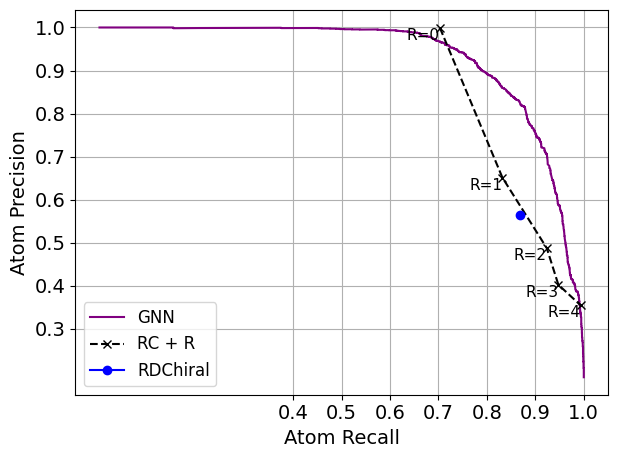

In [32]:
# RC + R stats
r_labels = [f"R={i}" for i in range(len(recall_from_rcr))]

precision, recall, thresholds = precision_recall_curve(pred_df.y, pred_df.y_pred)
fig, ax = plt.subplots()
ax.plot(recall, precision, color='purple', label="GNN")
ax.plot(recall_from_rcr, precision_from_rcr, ls='--', marker="x", color='black', label="RC + R")
print("GNN AUPRC:", auc(recall, precision))
print("RC + R AUPRC:", auc([0] + recall_from_rcr, [precision_from_rcr[0]] + precision_from_rcr))
ax.plot(
    rdchiral_metrics['recall'],
    rdchiral_metrics['precision'],
    marker='o',
    color='blue',
    label='RDChiral'
)
ax.set_xticks(np.arange(0.4, 1.05, 0.1))
ax.set_yticks(np.arange(0.3, 1.05, 0.1))
# ax.set_xlim(0.5, 1.05)
ax.set_xlabel("Atom Recall")
ax.set_ylabel("Atom Precision")
for r, p, label in zip(recall_from_rcr, precision_from_rcr, r_labels):
    ax.text(r, p, label, fontsize=11, ha='right', va='top', color='black')
ax.grid()
ax.legend(loc='lower left')
plt.tight_layout()
fig.savefig(Path(cfg.figures) / f"atom_precision_recall_curve_{experiment_name}.svg", format='svg')
plt.show()

In [37]:
ep = 9e-3
dts = []
for R, prec, rec_rcr in zip(Rs, precision_from_rcr, recall_from_rcr):
    print(f"Precision | {prec:.2f}")
    argequal_prec = np.flatnonzero(np.abs(precision - prec) < ep)[:-1]
    argmax_rec = np.argmax(recall[argequal_prec])
    print(f"Recall | GNN: {recall[argequal_prec][argmax_rec]:.2f} vs RC + {R}: {rec_rcr:.2f}")
    print(f"Threshold | {thresholds[argequal_prec][argmax_rec]:.3f}\n")
    dts.append(float(thresholds[argequal_prec][argmax_rec]))

print(dts)

Precision | 1.00
Recall | GNN: 0.64 vs RC + 0: 0.70
Threshold | 0.961

Precision | 0.65
Recall | GNN: 0.94 vs RC + 1: 0.83
Threshold | 0.244

Precision | 0.49
Recall | GNN: 0.96 vs RC + 2: 0.92
Threshold | 0.106

Precision | 0.40
Recall | GNN: 0.98 vs RC + 3: 0.95
Threshold | 0.059

Precision | 0.35
Recall | GNN: 0.99 vs RC + 4: 0.99
Threshold | 0.035

[0.9613090753555298, 0.2442730963230133, 0.1055898517370224, 0.05896127223968506, 0.03492005914449692]


In [38]:
rxn_recall_from_rcr = []
for R in Rs:
    print(f"Calculating reaction recall from RCR for R={R}")
    preds = rcr_preds[R]
    rxn_recovery_indicator = []
    for rxn_id in tqdm(np.unique(continuous_rxn_ids), total=len(np.unique(continuous_rxn_ids)), desc="Processing reactions"):
        if (preds[continuous_rxn_ids == rxn_id] - y[continuous_rxn_ids == rxn_id] >= 0).all():
            rxn_recovery_indicator.append(1)
        else:
            rxn_recovery_indicator.append(0)
    
    rxn_recall_from_rcr.append(sum(rxn_recovery_indicator) / len(rxn_recovery_indicator))

Calculating reaction recall from RCR for R=0


Processing reactions:   0%|          | 0/560 [00:00<?, ?it/s]

Processing reactions: 100%|██████████| 560/560 [00:00<00:00, 6041.58it/s]


Calculating reaction recall from RCR for R=1


Processing reactions: 100%|██████████| 560/560 [00:00<00:00, 5977.12it/s]


...

Processing reactions: 100%|██████████| 560/560 [00:00<00:00, 6350.59it/s]


Calculating reaction recall from RCR for R=3


Processing reactions: 100%|██████████| 560/560 [00:00<00:00, 6801.17it/s]


Calculating reaction recall from RCR for R=4


Processing reactions: 100%|██████████| 560/560 [00:00<00:00, 6087.10it/s]


In [39]:
rxn_recall = []
ds = 1_000
for dt in tqdm(thresholds[::ds], total=len(thresholds[::ds]), desc="Calculating reaction recall from GNN"):
    rxn_recovery_indicator = []
    for rxn_id, group in pred_df.groupby("rxn_id"):
        preds = (group.y_pred >= dt).astype(np.int32).to_numpy()
        ytrue = group.y.to_numpy()
        if (preds - ytrue >= 0).all():
            rxn_recovery_indicator.append(1)
        else:
            rxn_recovery_indicator.append(0)

    rxn_recall.append(sum(rxn_recovery_indicator) / len(rxn_recovery_indicator))

Calculating reaction recall from GNN: 100%|██████████| 9/9 [00:00<00:00, 10.60it/s]


GNN AUPRC: 0.7559826837304536
RC + R AUPRC: 0.6362098010931485


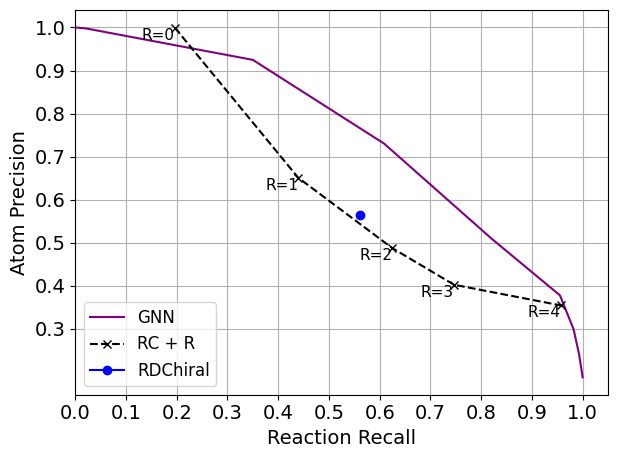

In [40]:
fig, ax = plt.subplots()
ax.plot(rxn_recall, precision[::ds], color='purple', label="GNN")
ax.plot(rxn_recall_from_rcr, precision_from_rcr, ls='--', marker="x", color='black', label="RC + R")
print("GNN AUPRC:", auc(rxn_recall, precision[::ds]))
print("RC + R AUPRC:", auc([0] + rxn_recall_from_rcr, [precision_from_rcr[0]] + precision_from_rcr))
ax.plot(
    rdchiral_metrics['rxn_recall'],
    rdchiral_metrics['precision'],
    marker='o',
    color='blue',
    label='RDChiral'
)
ax.set_xticks(np.arange(0.0, 1.05, 0.1))
ax.set_yticks(np.arange(0.3, 1.05, 0.1))
ax.set_xlim(0.0, 1.05)
ax.set_xlabel("Reaction Recall")
ax.set_ylabel("Atom Precision")
for r, p, label in zip(rxn_recall_from_rcr, precision_from_rcr, r_labels):
    ax.text(r, p, label, fontsize=11, ha='right', va='top', color='black')
ax.grid()
ax.legend(loc='lower left')
plt.tight_layout()
fig.savefig(Path(cfg.figures) / f"atom_precision_reaction_recall_curve_{experiment_name}.svg", format='svg')
plt.show()

/tmp/ipykernel_74127/2748991940.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_by_R = pred_df.groupby("min_dist_to_rc").apply(


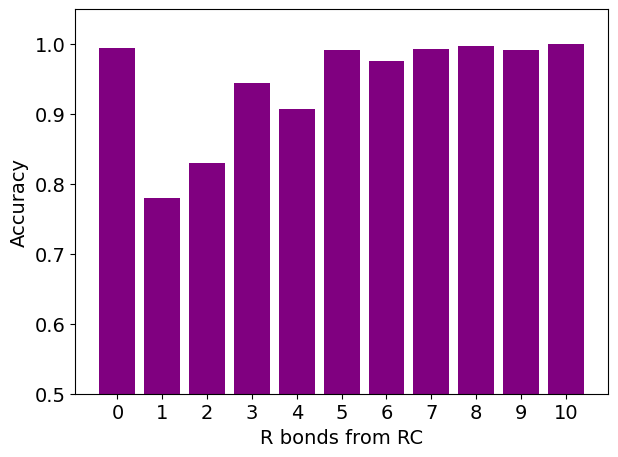

In [41]:
acc_by_R = pred_df.groupby("min_dist_to_rc").apply(
    lambda x: accuracy_score(x.y, x.y_pred >= 0.5)
).iloc[:11]

fig, ax = plt.subplots()
ax.bar(acc_by_R.index, acc_by_R.values, color='purple')
ax.set_xticks(acc_by_R.index)
ax.set_xlabel("R bonds from RC")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
fig.savefig(Path(cfg.figures) / f"accuracy_by_R_{experiment_name}.svg", format='svg')
plt.show()

/tmp/ipykernel_74127/3634696261.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  f1_by_rule = pred_df.groupby("rule_id").apply(


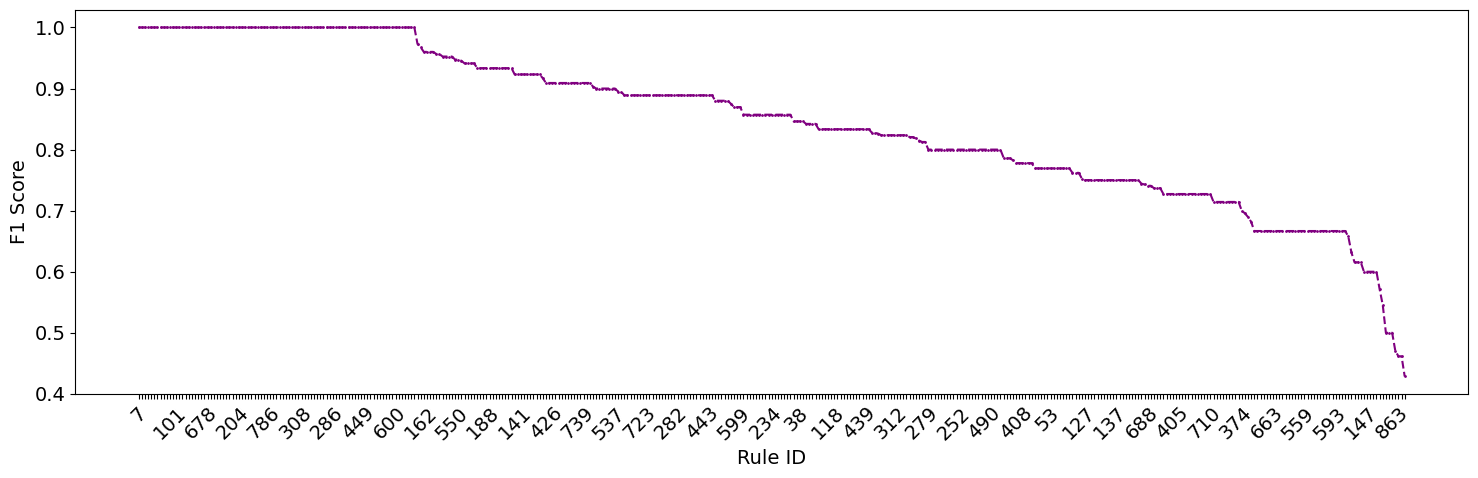

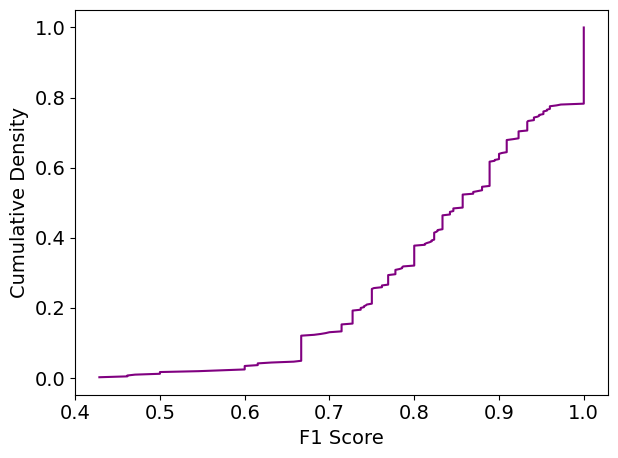

In [42]:
f1_by_rule = pred_df.groupby("rule_id").apply(
    lambda x: f1_score(x.y, x.y_pred >= 0.5)
).sort_values(ascending=False)
ds_lab = 10

fig, ax = plt.subplots(figsize=(15, 5))
xticks = np.arange(0, len(f1_by_rule))
ax.plot(f1_by_rule.values, color='purple', marker='o', markersize=1, ls='--')
ax.set_xticks(xticks)
xtick_labels = []
for i in range(len(f1_by_rule)):
    if i % ds_lab == 0:
        xtick_labels.append(f1_by_rule.index[i])
    else:
        xtick_labels.append(None)

ax.set_xticklabels(xtick_labels, rotation=45)
ax.set_xlabel("Rule ID")
ax.set_ylabel("F1 Score")
plt.tight_layout()
fig.savefig(Path(cfg.figures) / f"f1_by_mechinformed_rule_{experiment_name}.svg", format='svg')
plt.show()

srt_f1_by_rule = np.sort(f1_by_rule.values)
ycdf = np.arange(1, len(srt_f1_by_rule) + 1) / len(srt_f1_by_rule)
fig, ax = plt.subplots()
ax.plot(srt_f1_by_rule, ycdf, color='purple')
ax.set_xlabel("F1 Score")
ax.set_ylabel("Cumulative Density")
plt.tight_layout()
fig.savefig(Path(cfg.figures) / f"f1_by_mechinformed_rule_cdf_{experiment_name}.svg", format='svg')
plt.show()

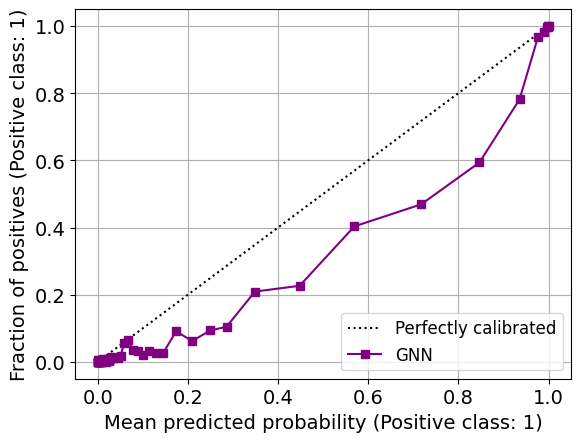

In [43]:
disp = CalibrationDisplay.from_predictions(
    pred_df.y,
    pred_df.y_pred,
    strategy="quantile",
    n_bins=50,
    name="GNN",
    color='purple',
)
plt.grid()
plt.show()

In [44]:
random_guess = np.random.choice([0, 1], size=pred_df.shape[0])
chance_f1 = f1_score(pred_df.y, random_guess)
chance_f1

0.27555363196999205